# Введение в машинное обучение

Лекция 1 · Курс «Машинное обучение», 4 курс

## Что такое обучение по прецедентам

- Есть объекты $x \in X$ и ответы $y \in Y$
- Известна конечная выборка $(x_i, y_i)_{i=1}^{\ell}$
- Нужно построить алгоритм $a: X \to Y$, который хорошо работает **на новых объектах**

> Ключевое слово — *обобщающая способность*, а не точность на обучающей выборке.

## Типы задач

| Задача | Ответы $Y$ | Пример |
|---|---|---|
| Регрессия | $\mathbb{R}$ | прогноз цены квартиры |
| Классификация | конечное множество | спам / не спам |
| Ранжирование | порядок | выдача поисковика |
| Кластеризация | нет разметки | сегментация клиентов |

## Схема эксперимента

1. Разделить данные: **train / validation / test**
2. Обучить модель на train
3. Подобрать гиперпараметры по validation (или кросс-валидации)
4. Один раз измерить качество на test

**Нельзя** подбирать гиперпараметры по тестовой выборке — оценка станет оптимистично смещённой.

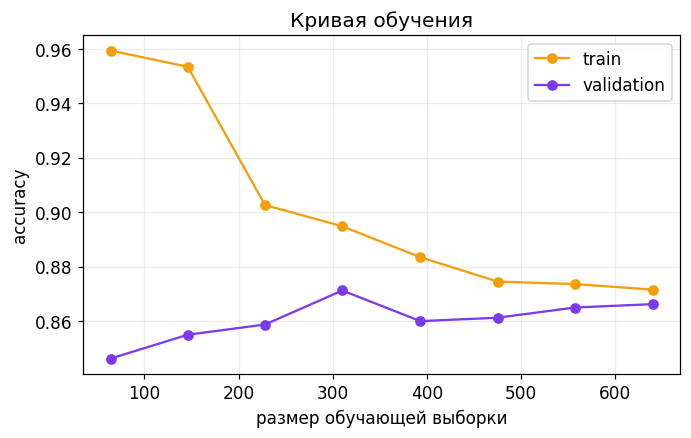

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({
    "figure.figsize": (7, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = np.random.default_rng(42)

from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=800, n_features=20, n_informative=5, random_state=0)
sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000), X, y, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=0)

plt.plot(sizes, train_scores.mean(axis=1), marker="o", label="train", color="#f59e0b")
plt.plot(sizes, val_scores.mean(axis=1), marker="o", label="validation", color="#7c3aed")
plt.xlabel("размер обучающей выборки"); plt.ylabel("accuracy")
plt.title("Кривая обучения")
plt.legend()
plt.show()

## Что дальше

- **Семинар 1** — линейная регрессия и градиентный спуск
- **Лекция 2** — переобучение, разложение ошибки, выбор модели
- Материалы и код: раздел **Notebooks** на сайте курса